# Imports

In [1]:
import torch
import torchvision
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import tempfile

from tqdm import tqdm
from torch import nn

In [2]:
torch.manual_seed(0)
np.random.seed(0)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [3]:
BATCH_SIZE = 128
MEAN, SD = 0.1307, 0.3081
LEARNING_RATE, MOMENTUM = 0.001, 0.9

# Dataloader

In [4]:
transform = transforms.Compose([
  transforms.ToTensor(),
  transforms.Normalize((MEAN,), (SD,)),
])

dataset_train = torchvision.datasets.MNIST(root=tempfile.gettempdir(), train=True, transform=transform, download=True)
dataloader_train = torch.utils.data.DataLoader(dataset=dataset_train, batch_size=BATCH_SIZE, shuffle=True)
dataset_test = torchvision.datasets.MNIST(root=tempfile.gettempdir(), train=False, transform=transform, download=True)
dataloader_test = torch.utils.data.DataLoader(dataset=dataset_test, batch_size=BATCH_SIZE, shuffle=True)

# LeNet

In [5]:
class LeNet(nn.Module):
  def __init__(self):
    super(LeNet, self).__init__()
    self.model = nn.Sequential(
      nn.Conv2d(1, 6, 5),
      nn.ReLU(),
      nn.MaxPool2d(2),
      nn.Conv2d(6, 16, 5),
      nn.ReLU(),
      nn.MaxPool2d(2),

      nn.Flatten(),
      nn.Linear(16*5*5, 120),
      nn.ReLU(),
      nn.Linear(120, 84),
      nn.ReLU(),
      nn.Linear(84, 10),
    )

  def forward(self, x):
    x = F.pad(x, (2, 2, 2, 2), value=-MEAN/SD)
    return self.model(x)

lenet = LeNet().to(device)

In [6]:
loss_function = nn.CrossEntropyLoss()
optimizer = optim.SGD(lenet.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

## Training

In [7]:
losses = []
accuracies = []
for epoch in range(2):  # loop over the dataset multiple times
    running_loss = 0.0
    pbar = tqdm(dataloader_train)
    pbar.set_description(f"epoch {epoch}")
    for i, (x, y) in enumerate(pbar):
        x, y = x.to(device), y.to(device) 
        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = lenet(x)
        loss = loss_function(outputs, y)
        loss.backward()
        losses.append(loss.item())

        preds = torch.argmax(outputs, dim=1)
        accuracy = (preds == y).float().mean()
        accuracies.append(accuracy.item())
        optimizer.step()

        # print statistics
        pbar.set_postfix_str(f"loss {loss:.2f}, accuracy {accuracy:.2f}")

epoch 1: 100%|██████████| 469/469 [00:11<00:00, 40.83it/s, loss 0.20, accuracy 0.96]


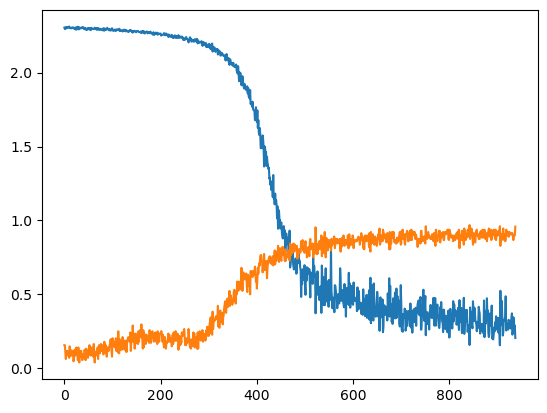

In [8]:
plt.plot(losses)
plt.plot(accuracies)

## Validate

In [9]:
correct = 0
total = 0
with torch.no_grad():
    for x, y in dataloader_test:
        x, y = x.to(device), y.to(device) 
        outputs = lenet(x)
        preds = torch.argmax(outputs.data, dim=1)
        total += y.size(0)
        correct += (preds == y).sum().item()

print(f"accuracy {correct / total:.4f}")

accuracy 0.9209


# LinNet

In [10]:
class LinNet(nn.Module):
  def __init__(self):
    super(LinNet, self).__init__()
    self.model = nn.Sequential(
      nn.Flatten(),
      nn.Linear(28*28, 128, bias=False),
      nn.ReLU(),
      nn.Linear(128, 10, bias=False),
      nn.LogSoftmax(dim=1),
    )

  def forward(self, x):
    return self.model(x)

linnet = LinNet().to(device)

In [11]:
loss_function = nn.NLLLoss()
optimizer = optim.SGD(linnet.parameters(), lr=LEARNING_RATE, momentum=MOMENTUM)

## Training

In [12]:
losses = []
accuracies = []
for epoch in range(4):  # loop over the dataset multiple times
    running_loss = 0.0
    pbar = tqdm(dataloader_train)
    pbar.set_description(f"epoch {epoch}")
    for i, (x, y) in enumerate(pbar):
        x, y = x.to(device), y.to(device) 
        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = linnet(x)
        loss = loss_function(outputs, y)
        loss.backward()
        losses.append(loss.item())

        preds = torch.argmax(outputs, dim=1)
        accuracy = (preds == y).float().mean()
        accuracies.append(accuracy.item())
        optimizer.step()

        # print statistics
        pbar.set_postfix_str(f"loss {loss:.2f}, accuracy {accuracy:.2f}")

epoch 3: 100%|██████████| 469/469 [00:03<00:00, 153.63it/s, loss 0.43, accuracy 0.83]


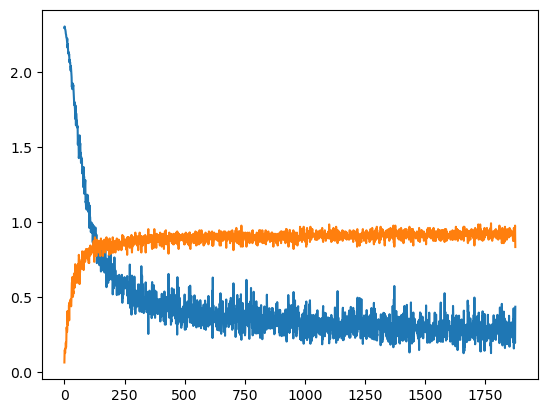

In [13]:
plt.plot(losses)
plt.plot(accuracies)

## Validate

In [14]:
correct = 0
total = 0
with torch.no_grad():
    for x, y in dataloader_test:
        x, y = x.to(device), y.to(device) 
        outputs = linnet(x)
        preds = torch.argmax(outputs.data, dim=1)
        total += y.size(0)
        correct += (preds == y).sum().item()

print(f"accuracy {correct / total:.4f}")

accuracy 0.9263


## Export model to test scratch MNIST

In [15]:
def save_params(model, path="data/"):
  for i, param in enumerate(model.parameters()):
    np.save(f"{path}{i}", param.detach().numpy())

save_params(linnet)